## Why do we need DBSCAN?

In clustering, not all algorithms perform well across different types of datasets. K-Means is widely used, but it has several limitations that make it unsuitable in many real-world scenarios.

**Limitations of K-Means:**

1. **Need to specify number of clusters (K):**  
   K-Means requires the number of clusters to be defined beforehand. In practice, this value is often unknown. Methods like the elbow curve are used, but they can be ambiguous and do not always give a clear answer.

2. **Sensitivity to outliers:**  
   Since K-Means is based on centroids (mean), the presence of outliers can significantly shift the cluster centers, leading to incorrect clustering.

3. **Assumption of spherical clusters:**  
   K-Means works best when clusters are convex and spherical. However, many real-world datasets contain non-spherical or irregularly shaped clusters, where K-Means performs poorly.

4. **Poor performance on complex data:**  
   When clusters have varying densities, overlapping regions, or arbitrary shapes, K-Means fails to capture the true structure of the data.

**Why DBSCAN is useful:**

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) addresses these issues by using a density-based approach.

- It does not require specifying the number of clusters in advance.
- It is robust to outliers by explicitly identifying noise points.
- It can detect clusters of arbitrary shapes.
- It works well when clusters are defined by dense regions in the data.

In summary, while K-Means performs well under certain assumptions, DBSCAN is more suitable for datasets with unknown structure, noise, and complex cluster shapes.

---------

## Density-Based Clustering Algorithms

K-Means is a centroid-based algorithm, where clusters are formed around the mean of data points.

In contrast, density-based clustering algorithms group data based on the density of points in a region.

The main idea is:
- Regions with high point density form clusters  
- Regions with low density are treated as noise or boundaries  

Such algorithms can separate clusters of different shapes and structures, especially when the data is not spherical.

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise):**  
A widely used density-based algorithm that forms clusters based on dense regions and labels sparse points as noise.

**OPTICS (Ordering Points To Identify the Clustering Structure):**  
Another density-based algorithm that improves upon DBSCAN by handling varying densities more effectively.

## Example (DBSCAN intuition)

Let  
$$
\epsilon = 1, \quad \text{minPts} = 3
$$

If a point has at least $$3$$ points (including itself) within a radius of $$\epsilon = 1$$, then it is considered a **core (dense) point**.

In general, the density around a point is determined using:
$$
\text{Neighborhood}(x) = \{ y \mid \text{dist}(x, y) \le \epsilon \}
$$

A point is a core point if:
$$
|\text{Neighborhood}(x)| \ge \text{minPts}
$$

Here, $$\epsilon$$ and $$\text{minPts}$$ are **hyperparameters** that control cluster formation.

-----

#### Core Points, Border Points, and Noise Points

Let  
$$
\mathcal{N}_\epsilon(x) = \{ y \mid \text{dist}(x, y) \le \epsilon \}
$$

**Core Point:**  
A point \( x \) is a core point if:
$$
|\mathcal{N}_\epsilon(x)| \ge \text{minPts}
$$

**Border Point:**  
A point \( x \) is a border point if:
$$
|\mathcal{N}_\epsilon(x)| < \text{minPts}
$$
but it lies within the \( \epsilon \)-neighborhood of at least one core point.

**Noise Point (Outlier):**  
A point is a noise point if it is neither a core point nor a border point, i.e., it is not density-reachable from any core point.

---

#### Density-Connected Points

Two points \( A \) and \( B \) are said to be **density-connected** if they can be placed in the same cluster through a chain of core points.

Formally, \( A \) and \( B \) are density-connected if there exists a sequence of points  
$$
x_1, x_2, \dots, x_n
$$
such that:
$$
x_1 = A, \quad x_n = B
$$
and for every consecutive pair:
$$
\text{dist}(x_i, x_{i+1}) \le \epsilon
$$
with all intermediate points being **core points**.

This means \( A \) and \( B \) are indirectly connected through a path of dense regions.

**Cases where two points are not density-connected:**

- If the distance between adjacent core points exceeds \( \epsilon \)  
- If a noise point breaks the chain (i.e., no valid core-point path exists)

---
# DBSCAN Algo.

#### (Steps)

**Step 0:**  
Choose the hyperparameters:
$$
\epsilon, \quad \text{minPts}
$$

**Step 1:**  
Classify each point as:
- Core point  
- Border point  
- Noise point  

based on:
$$
|\mathcal{N}_\epsilon(x)| \ge \text{minPts}
$$

**Step 2:**  
For each unclustered core point:

- Create a new cluster  
- Add all points that are density-connected to this core point into the cluster  

**Step 3:**  
For each unclustered border point:

- Assign it to the cluster of its nearest core point  

**Step 4:**  
Leave all noise points as they are (not assigned to any cluster)

## Implementing in Sklearn

In [1]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

In [48]:
X, _ = make_moons(n_samples=100, noise=0.05, random_state=42)

In [49]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

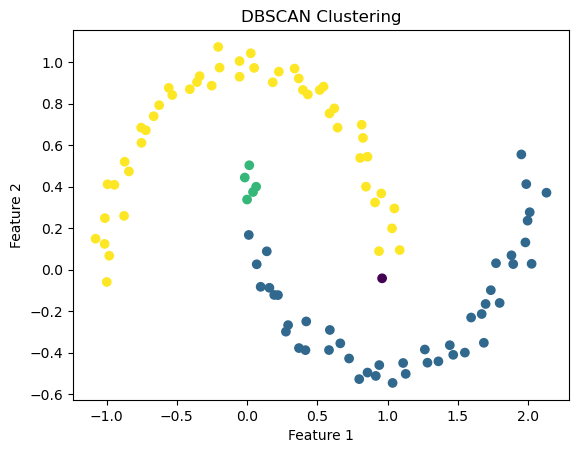

In [50]:
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

#### Concecentric circle dataset

In [51]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

In [61]:
X, _ = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

In [70]:
dbscan = DBSCAN(eps=0.15, min_samples=2)
labels = dbscan.fit_predict(X)

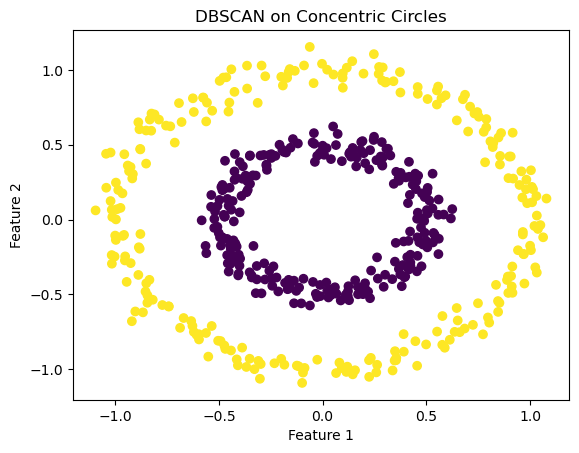

In [71]:
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("DBSCAN on Concentric Circles")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Advantages and Disadvantages of DBSCAN

**Advantages:**

- Robust to outliers (explicitly labels noise points)  
- No need to specify the number of clusters beforehand  
- Can detect clusters of arbitrary (non-spherical) shapes  
- Requires only two hyperparameters:
$$
\epsilon, \quad \text{minPts}
$$

**Disadvantages:**

- Highly sensitive to the choice of hyperparameters  
- Struggles with datasets having varying density (single \( \epsilon \) may not fit all regions)  
- Does not provide a natural `predict` method for new/unseen data (primarily works on the fitted dataset)

[WebsiteToVisualize](https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/)